# PART 1

In [1]:
# Standard imports
import numpy as np

# Utils
from config import *
from utils.segment import *
from utils.display import loadAndDisplay, getSlice
from utils.filtering import *

from IPython.display import display # for better visualization in Jupyter notebook

In [2]:
# In this part theese are all the data we need
t1_dict   = loadAndDisplay(T1_PATH, "T1-WEIGHTED", print_summary=False)
mask_dict = loadAndDisplay(MASK_PATH, 'MASK', print_summary=False)
fmri_dict = loadAndDisplay(FMRI_PATH, "FMRI", print_summary=False)

## T1-Brain extraction
Here I want to put to zero every value that is outside the valid points of the mask --> np.where is the best function to use, and we can apply it by using a boolean mask

In [3]:
bool_mask = mask_dict['data'].astype(bool)
t1_brain = np.where(bool_mask, t1_dict['data'], 0) # np.where keep the same dimension of the starting array.
np.save('data/part1/t1_brain.npy', t1_brain)

## Tissue Segmentation
In these cells I will perform tissue segmentation, trying different methods and comparing them. Most of the library methods that implement segmentation techniques require the input data to be in the form
of (samples, features), so the first thing I need to do is to vectorize my data.
These are some of the methods I'm implementing:
- K-Mean
- Multithreshold Otsu

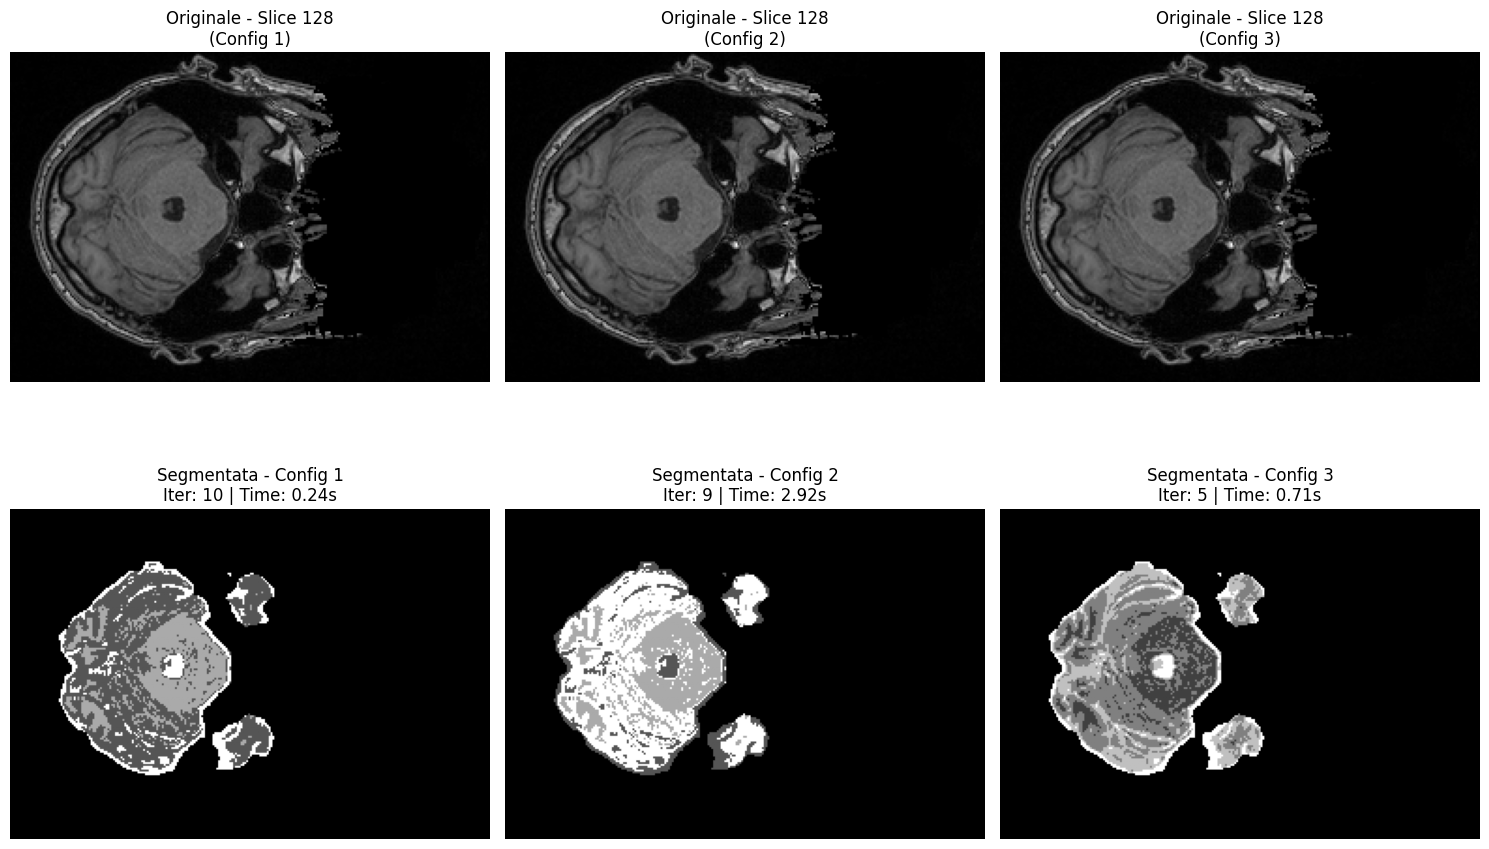

,config_id,n_clusters,init,algorithm,time_sec,n_iter,inertia,n_features,pixels_per_label
0,1,3,k-means++,lloyd,0.241,10,2.120982e+09,1,"{0: 650881, 1: 642433, 2: 221737}"
1,2,3,random,elkan,2.922,9,2.120982e+09,1,"{0: 221737, 1: 642433, 2: 650881}"
2,3,4,k-means++,lloyd,0.707,5,1.285953e+09,1,"{0: 534405, 1: 566800, 2: 262224, 3: 151622}"


In [4]:
# 1) Vectorize the data structure
t1_brain_vect = t1_dict['data'][bool_mask]
t1_brain_vect = t1_brain_vect.reshape(t1_brain_vect.shape[0],-1) # for the correct shape (n_samples x n_features)

configs = [
    {'n_clusters': 3, 'init': 'k-means++', 'n_init': 'auto', 'max_iter': 300, 'algorithm': 'lloyd', 'random_state': 42},
    {'n_clusters': 3, 'init': 'random', 'n_init': 10, 'max_iter': 300, 'algorithm': 'elkan', 'random_state': 42},
    {'n_clusters': 4, 'init': 'k-means++', 'n_init': 5, 'max_iter': 100, 'algorithm': 'lloyd', 'random_state': 42}
]

results_kmeans, kmeans_slices = kMeansSegmentation(t1_dict['data'], t1_brain_vect, bool_mask, configs, axis=2)
display(results_kmeans)

### Results K-Mean
- Config 1 and 2 produce different colors but the overall segmentation is the same. Lot of salt and pepper noise due to purely euclidean distance used for pixels clustering (similar colors = same group, even though two pixels are in the same region)
- Config 3 is a over-segmentation, it's clearly grouping too many groups of pixels. 
- The config number 1 is the best one in terms of efficiency and quality of the segmentation

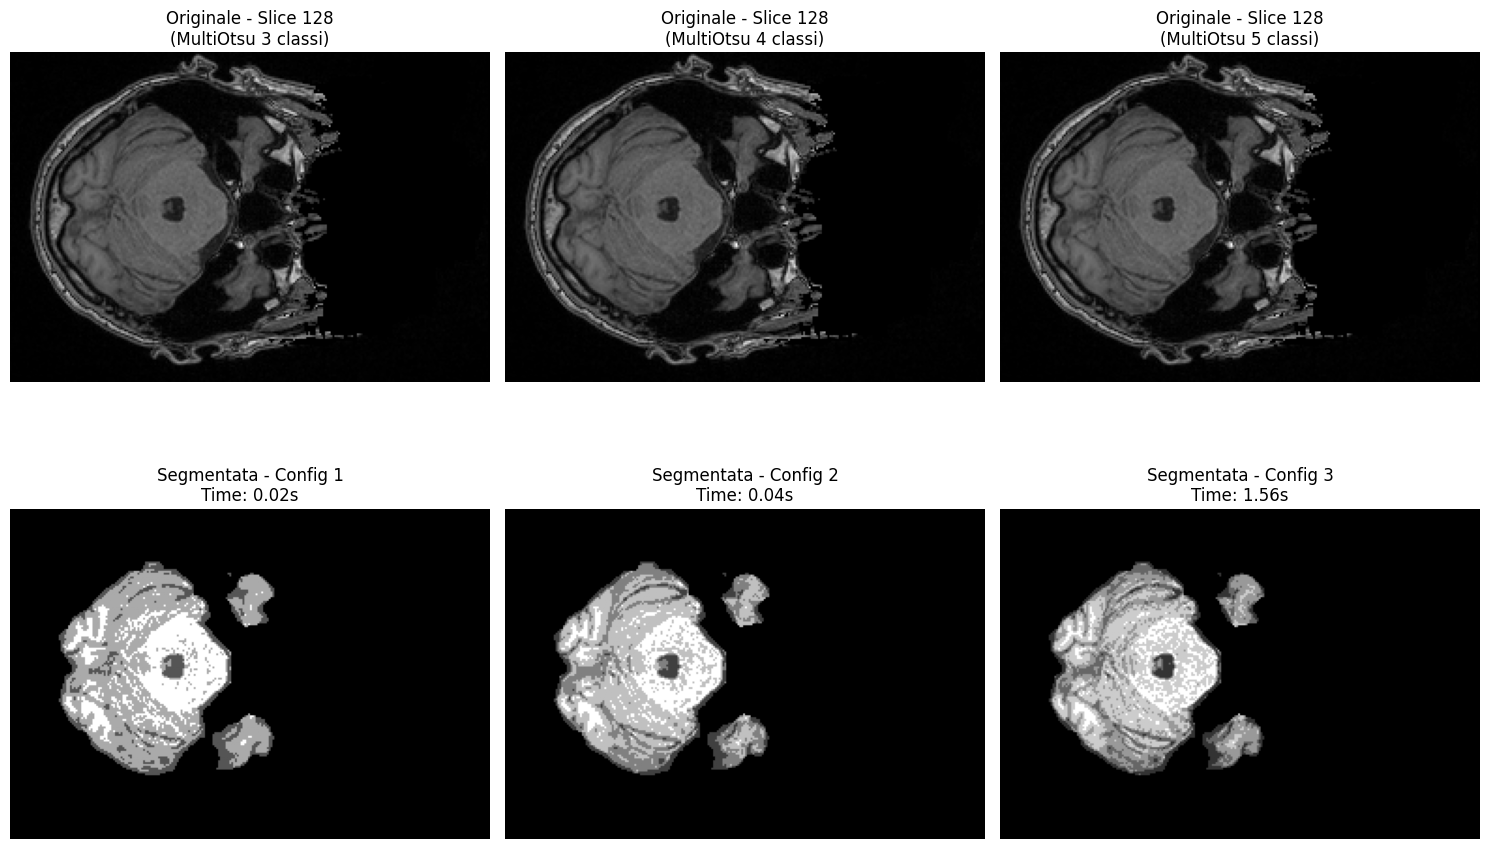

,config_id,classes,time_sec,thresholds,pixels_per_label
0,1,3,0.020,"[251.65, 385.39]","{0: 219859, 1: 646187, 2: 649005}"
1,2,4,0.044,"[205.89, 315.0, 402.99]","{0: 147575, 1: 247629, 2: 573918, 3: 545929}"
2,3,5,1.563,"[181.26, 279.8, 353.71, 417.06]","{0: 116338, 1: 163776, 2: 355642, 3: 419236, 4..."


In [5]:
configs_otsu = [
    {'classes': 3},  # background, CSF/GM, WM
    {'classes': 4},  # background, CSF, GM, WM
    {'classes': 5}   # over-segmentation
]

t1_brain_vect = t1_dict['data'][bool_mask]

results_otsu, otsu_slices = otsuSegmentation(t1_dict['data'], t1_brain_vect, bool_mask, configs_otsu, axis=2)
display(results_otsu)

Results Otsu:
- Fastest alorithm w.r.t K-mean because it works on the histogram of the image
- Config 3: over segmentation, captures more shades of colors
- Timing get higher and higher as the num. of classes increase
- Congig 1: extremely fast, but very flat

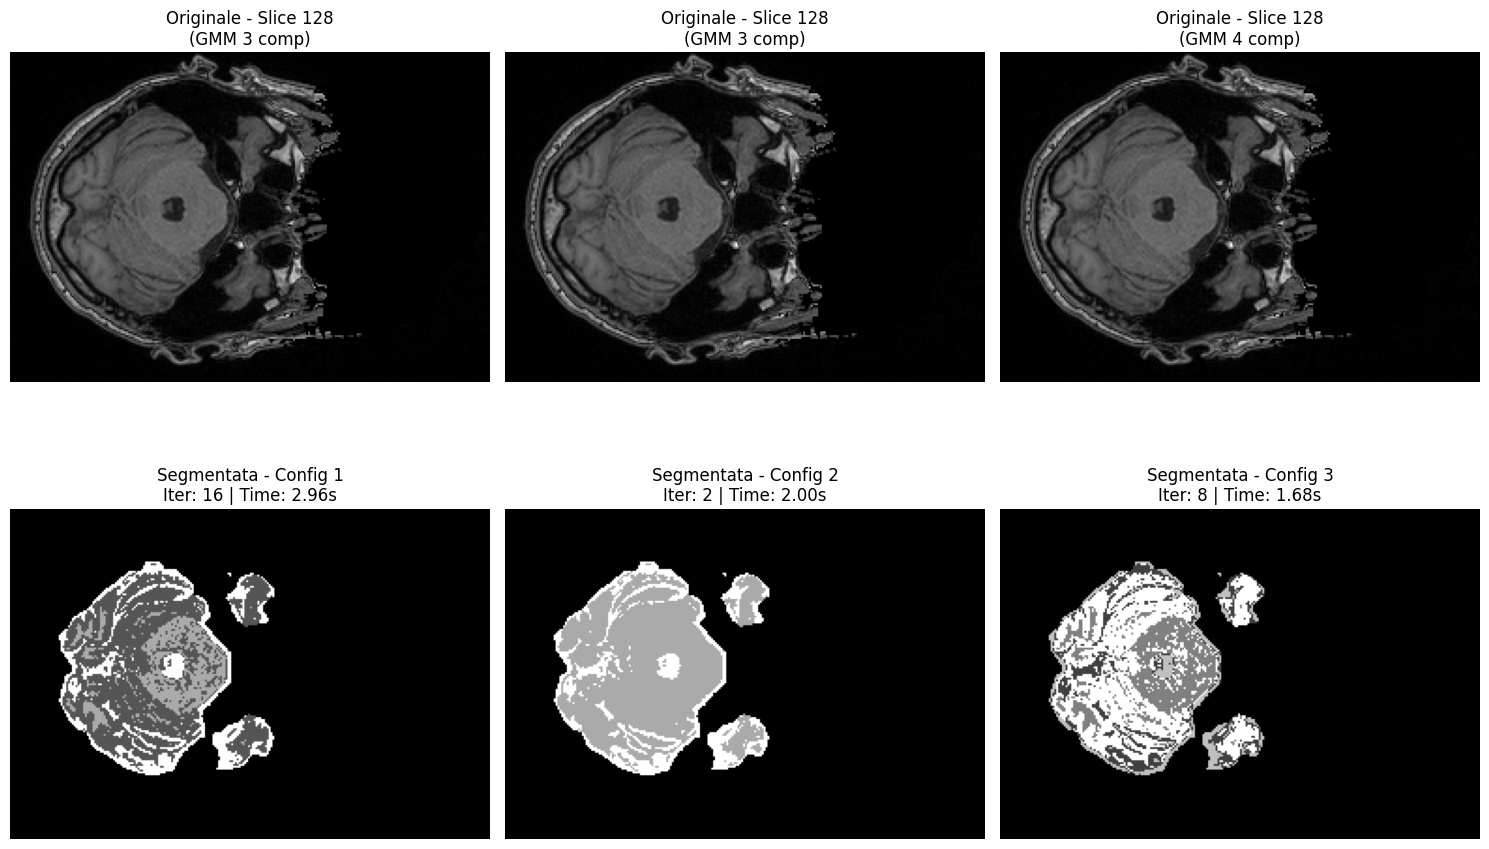

,config_id,n_components,covariance_type,time_sec,n_iter,converged,bic,aic,pixels_per_label
0,1,3,full,2.959,16,True,17757040.36,17756942.51,"{0: 687907, 1: 532719, 2: 294425}"
1,2,3,full,1.998,2,True,18174947.59,18174849.74,"{1: 1200827, 2: 314224}"
2,3,4,tied,1.685,8,True,17840399.21,17840301.37,"{0: 177368, 1: 574785, 2: 128899, 3: 633999}"


In [6]:
gmm_configs = [
    {
        'n_components': 3,
        'covariance_type': 'full',
        'init_params': 'kmeans',
        'max_iter': 100,
        'random_state': 42,
    },
    {
        'n_components': 3,
        'covariance_type': 'full',
        'init_params': 'random',
        'n_init': 5,
        'max_iter': 150,
        'random_state': 42,
    },
    {
        'n_components': 4,
        'covariance_type': 'tied',
        'init_params': 'kmeans',
        'max_iter': 100,
        'random_state': 42,
    },
]

results_gmm, gmm_slices = gmmSegmentation(t1_dict['data'], t1_brain_vect, bool_mask, gmm_configs, axis=2)
display(results_gmm)

Results GMM:
- Config 2 clearly wrong, 3 classes are specified but only 2 are found, because of unlucky initialization
- As num. of classes increase timing decrease, also the number of iterations
- Config 1 is the best one

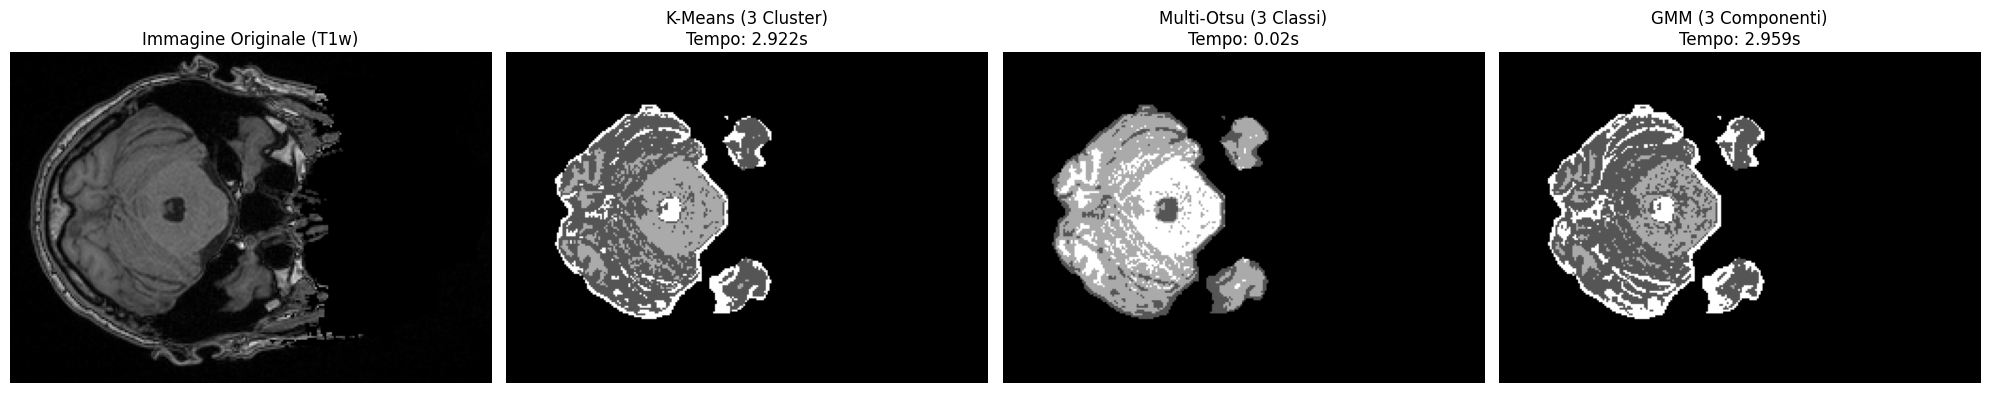

,config_id,n_clusters,init,algorithm,time_sec,n_iter,inertia,n_features,pixels_per_label,classes,thresholds,n_components,covariance_type,converged,bic,aic
K-Means,2,3.0,random,elkan,2.922,9.0,2.120982e+09,1.0,"{0: 221737, 1: 642433, 2: 650881}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
Multi-Otsu,1,NaN,NaN,NaN,0.020,NaN,NaN,NaN,"{0: 219859, 1: 646187, 2: 649005}",3.0,"[251.65, 385.39]",NaN,NaN,NaN,NaN,NaN
GMM,1,NaN,NaN,NaN,2.959,16.0,NaN,NaN,"{0: 687907, 1: 532719, 2: 294425}",NaN,NaN,3.0,full,True,17757040.36,17756942.51


In [7]:
kmeans_good_config = results_kmeans.iloc[1].to_dict()
otsu_good_config = results_otsu.iloc[0].to_dict()
gmm_good_config = results_gmm.iloc[0].to_dict()

total_results = compareSegmentationMethods(otsu_slices[0], kmeans_slices[1], otsu_slices[1], gmm_slices[1],
                                           kmeans_good_config, otsu_good_config, gmm_good_config)
display(total_results)

## Low Pass Filtering - Edge Detection
These are the steps to implement
1) Select an axial slice (randomnly or givigin an index)
2) Transform the slice in the frequency domain with 2D Discrete Fourier Transform
3) Centering the frequencies
4) Extract the magnitude image
5) Implement low pass filters on this image: try butter worth, gaussian, step function...
6) Edge detection: try different methods (first derivative mask, second derivative, Canny, Sobel, Prewitt)

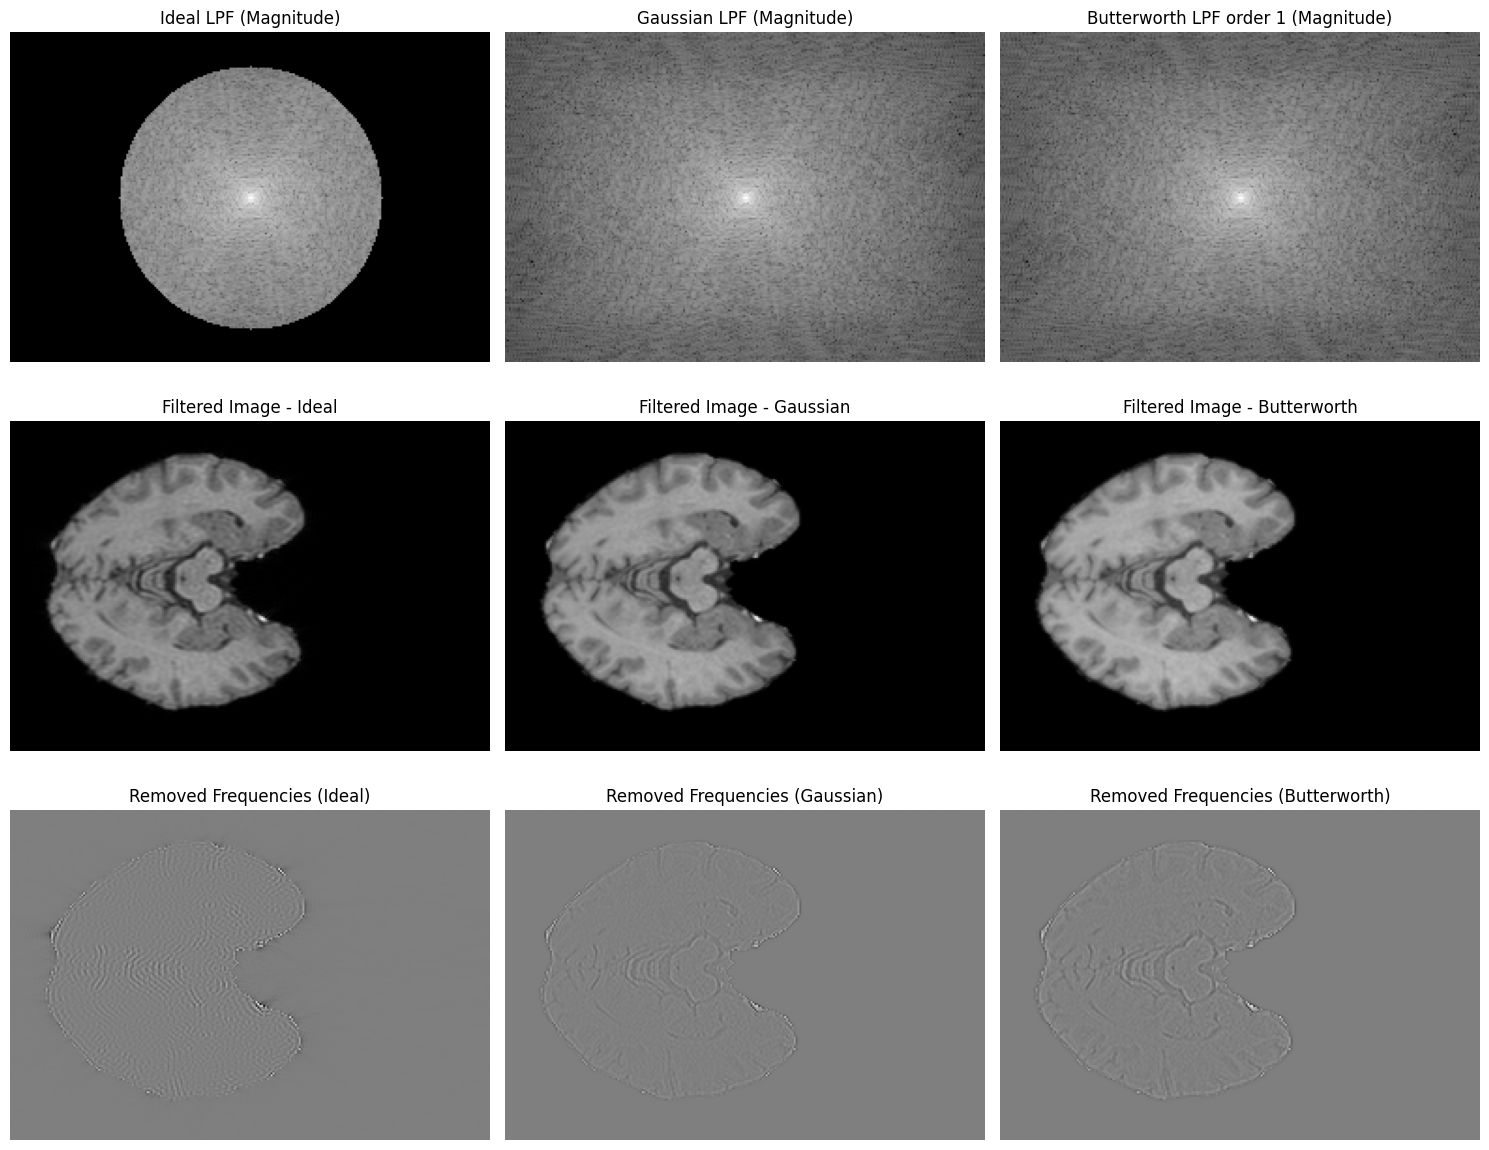

In [15]:
noisy_slice, _ = getSlice(t1_brain, slice_idx=150, axis='axial')
ideal_clean, gaussian_clean, butterw_clean = freqLowPassFilter(noisy_slice, 70, order=1)

Notice how the ideal filter produces the ringing effect, while the other two are much better

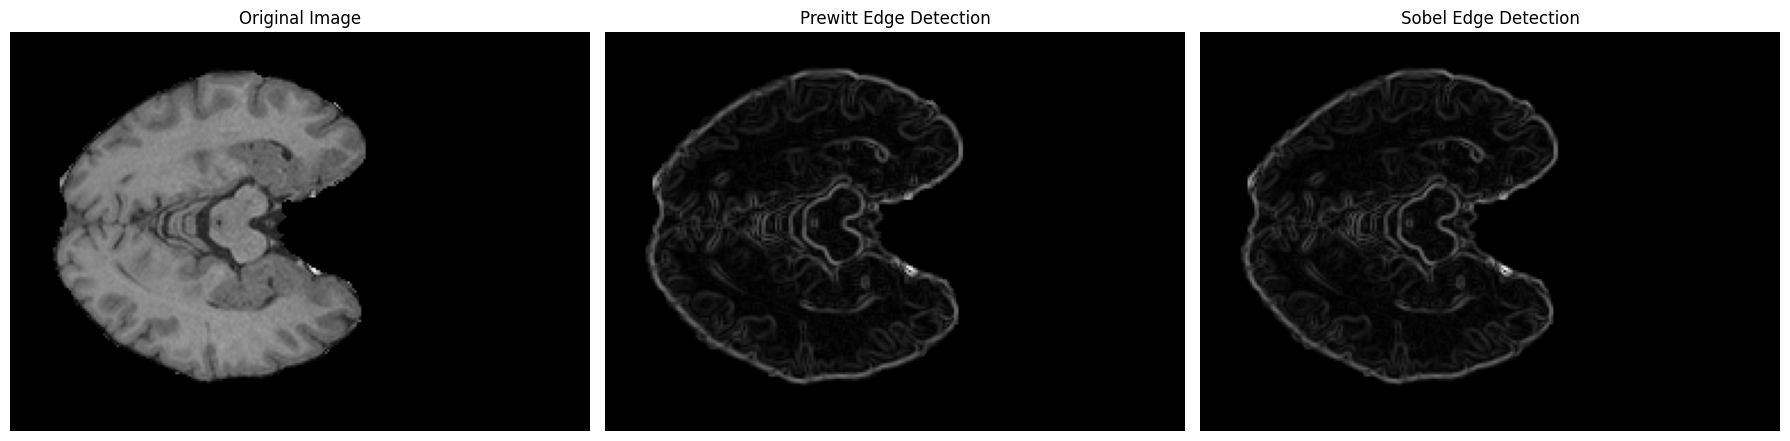

In [9]:
slice_prova, _ = getSlice(t1_brain, slice_idx=150)
prewitt_edges, sobel_edges = firstDerivativeEdgeDetection(slice_prova)

First derivative edge detection creates thicker edges, because the first derivative is positive along all the ramp where the intensity increase/decrease

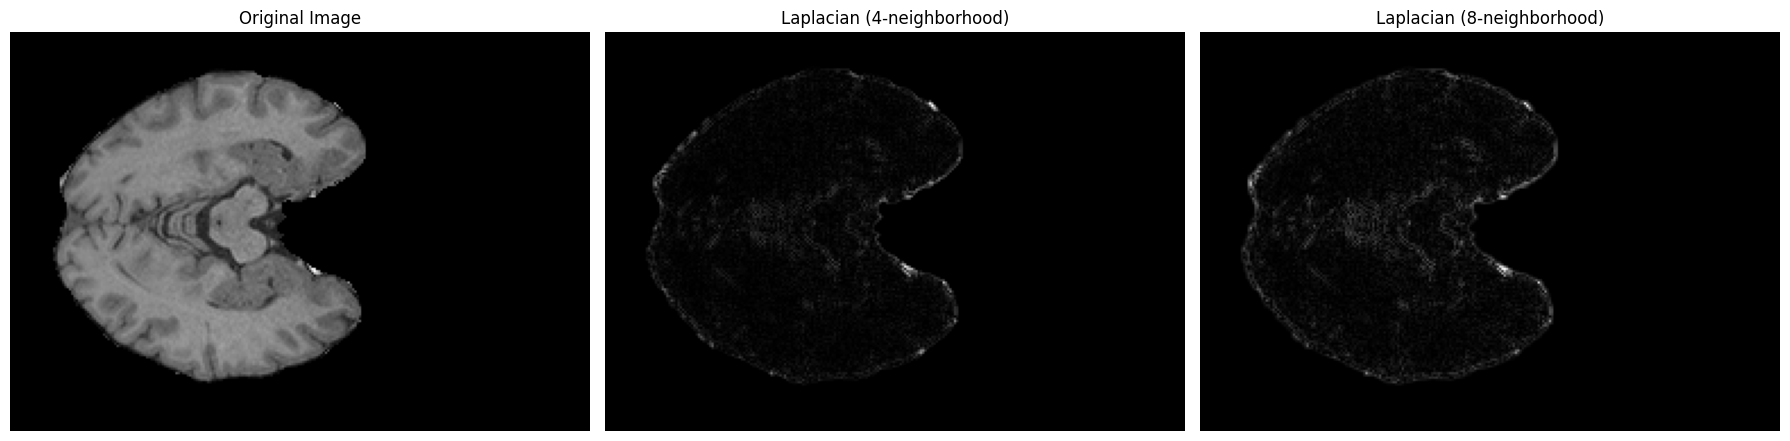

In [10]:
laplacian_45, laplacian_90 = secondDerivativeEdgeDetection(slice_prova)

Extraction of edges looking at zero-crossing, produces thinner edges, because the second derivative is != 0 only at the beginning and at the end of the ramp, while in the middle the values is 0 --> zero-crossing

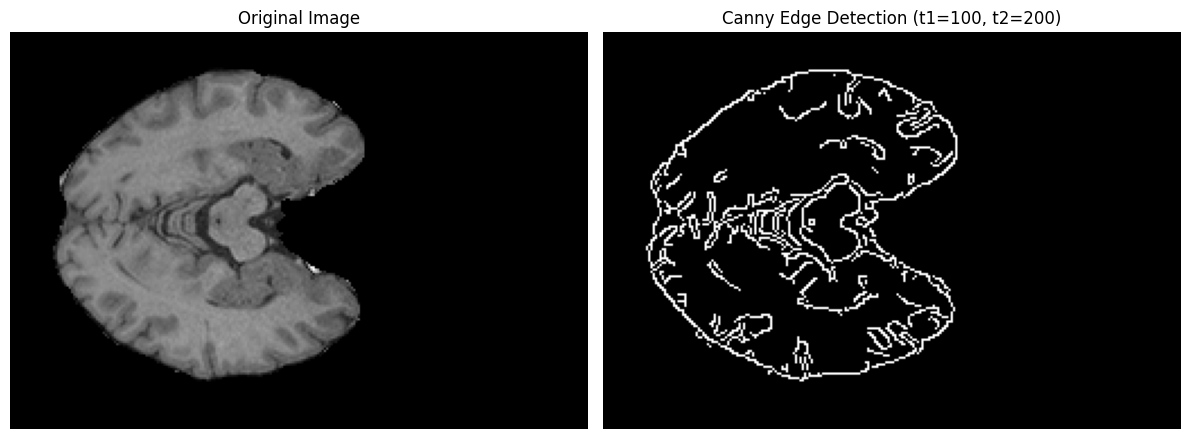

In [11]:
canny_edges = cannyEdgeDetection(slice_prova)

best method among all, it's a complex algorithm that comprises blurring + non maxima suppression + hystheresis thresholding --> produces the best results

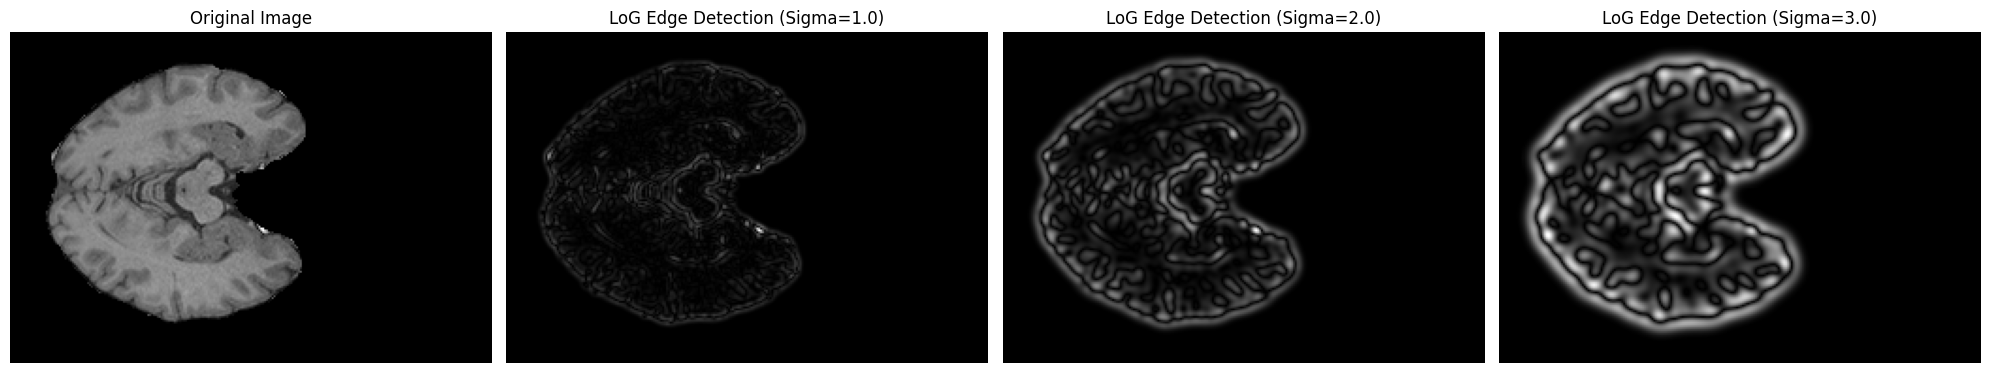

In [12]:
log_edges = logEdgeDetection(slice_prova)

## On fmri4d data apply gaussian smoothing on all the volumes to obtain fmri4d_smoothed

For this part I'm asked to perform gaussian smoothing not on 2d images but on 3d structures, so I cannot use cv.GaussianBlur that performs a blurring on 2D images --> looking on internet I see that scipy.ndimage.gaussian_filter performs a smoothing on n-dim images

In [13]:

fmri_smoothed = fmriVolumesSmoothing(fmri_dict['data'])
np.save('data/part1/fmri_smoothed.npy', fmri_smoothed)